# Data Playground

Demo notebook for `Trial` and `load_trials()` — load stimulus packages and inspect the 2AFC trial structure.

In [1]:
import os
import sys
import base64
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dotenv import load_dotenv
load_dotenv()

from PIL import Image
from IPython.display import display, HTML
from evaluation_pipe.data import Trial, load_trials

IMAGE_DATASET = REPO_ROOT / os.environ["IMAGE_DATASET"]
print(f"IMAGE_DATASET={IMAGE_DATASET}")

THUMB_SIZE = 200

def _img_to_b64(img: Image.Image, size: int = THUMB_SIZE) -> str:
    thumb = img.copy()
    thumb.thumbnail((size, size))
    buf = BytesIO()
    thumb.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()

def show_trial(ref, img_a, img_b, a_label="A", b_label="B"):
    cells = ""
    for img, label in [(ref, "Reference"), (img_a, a_label), (img_b, b_label)]:
        b64 = _img_to_b64(img)
        cells += f'<td style="text-align:center"><b>{label}</b><br><img src="data:image/png;base64,{b64}"></td>'
    display(HTML(f"<table><tr>{cells}</tr></table>"))

IMAGE_DATASET=/spark2/julio/langcog_hackathon/shapebias-bench/stimuli_pipe/stimuli_per_stl_packages/stimuli_A_auto_contrast


## Load trials — shape_first

30 trials loaded (order=shape_first)


Reference,A (shape_match),B (texture_match)

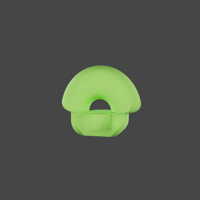
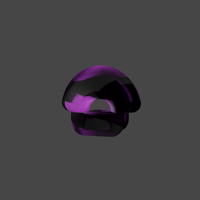
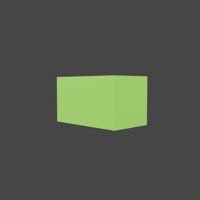

Reference,A (shape_match),B (texture_match)

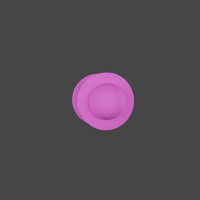
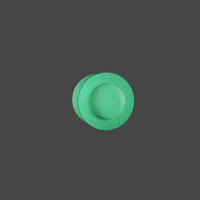
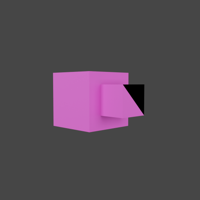

Reference,A (shape_match),B (texture_match)

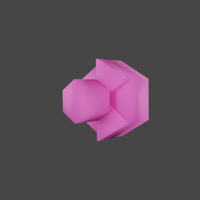
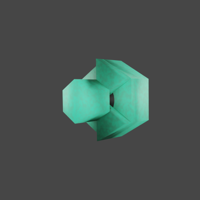
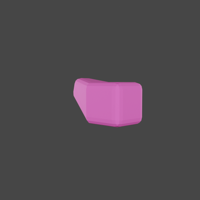

In [2]:
trials_sf = load_trials(IMAGE_DATASET, order="shape_first")
print(f"{len(trials_sf)} trials loaded (order=shape_first)")

for t in trials_sf[:3]:
    ref, img_a, img_b = t.load_images()
    display(HTML(f"<b>Trial {t.trial_id} | order={t.order} | ground_truth={t.ground_truth}</b>"))
    show_trial(ref, img_a, img_b, "A (shape_match)", "B (texture_match)")

## Load trials — texture_first

30 trials loaded (order=texture_first)


Reference,A (texture_match),B (shape_match)

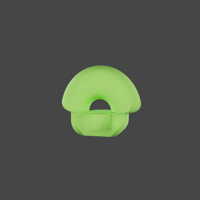
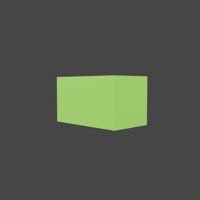
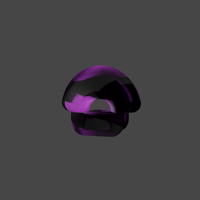

Reference,A (texture_match),B (shape_match)

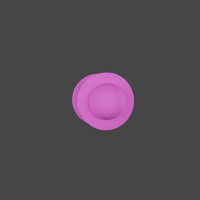
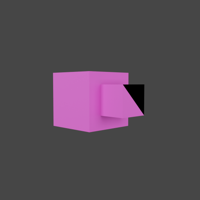
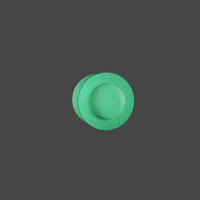

Reference,A (texture_match),B (shape_match)

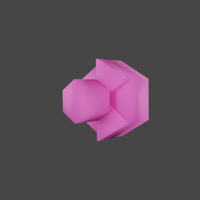
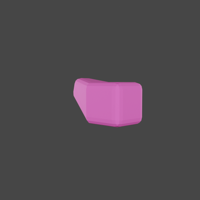
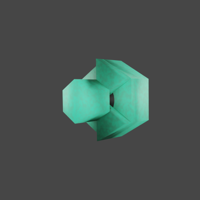

In [3]:
trials_tf = load_trials(IMAGE_DATASET, order="texture_first")
print(f"{len(trials_tf)} trials loaded (order=texture_first)")

for t in trials_tf[:3]:
    ref, img_a, img_b = t.load_images()
    display(HTML(f"<b>Trial {t.trial_id} | order={t.order} | ground_truth={t.ground_truth}</b>"))
    show_trial(ref, img_a, img_b, "A (texture_match)", "B (shape_match)")

## Load trials — random

30 trials loaded (order=random, seed=42)


Reference,A (shape_match),B (texture_match)

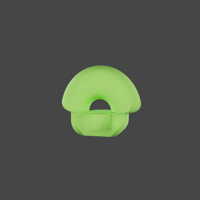
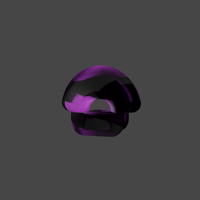
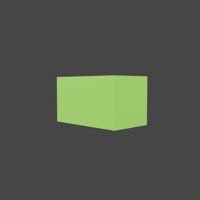

Reference,A (shape_match),B (texture_match)

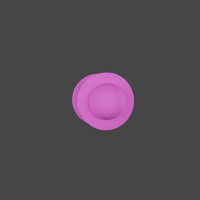
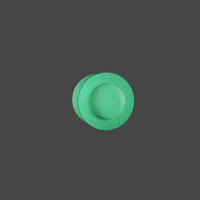
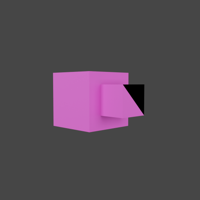

Reference,A (texture_match),B (shape_match)

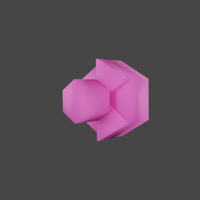
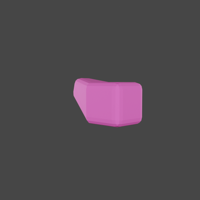
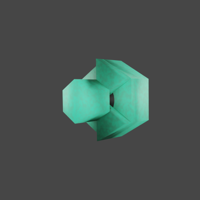

Reference,A (shape_match),B (texture_match)

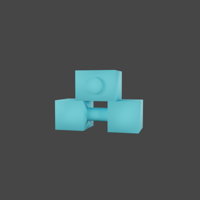
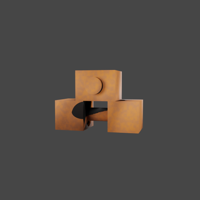
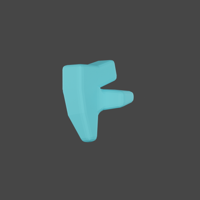

Reference,A (shape_match),B (texture_match)

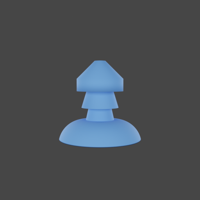
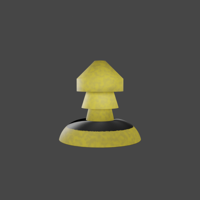
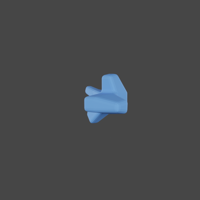

In [4]:
trials_rand = load_trials(IMAGE_DATASET, order="random", seed=42)
print(f"{len(trials_rand)} trials loaded (order=random, seed=42)")

for t in trials_rand[:5]:
    ref, img_a, img_b = t.load_images()
    a_label = "shape_match" if t.order == "shape_first" else "texture_match"
    b_label = "texture_match" if t.order == "shape_first" else "shape_match"
    display(HTML(f"<b>Trial {t.trial_id} | order={t.order} | ground_truth={t.ground_truth}</b>"))
    show_trial(ref, img_a, img_b, f"A ({a_label})", f"B ({b_label})")

## Inspect a single trial

In [5]:
t = trials_sf[0]
print(f"trial_id:       {t.trial_id}")
print(f"mode:           {t.mode}")
print(f"order:          {t.order}")
print(f"reference_path: {t.reference_path}")
print(f"image_a_path:   {t.image_a_path}")
print(f"image_b_path:   {t.image_b_path}")
print(f"ground_truth:   {t.ground_truth}")
print()
# Verify: for shape_first, ground_truth should be 'A' and image_a should contain 'shape_match'
assert t.ground_truth == "A", f"Expected 'A', got '{t.ground_truth}'"
assert "shape_match" in str(t.image_a_path), f"Expected shape_match in image_a, got {t.image_a_path}"
assert "texture_match" in str(t.image_b_path), f"Expected texture_match in image_b, got {t.image_b_path}"
print("All assertions passed!")

trial_id:       1
mode:           stimuli_A_auto_contrast
order:          shape_first
reference_path: /spark2/julio/langcog_hackathon/shapebias-bench/stimuli_pipe/stimuli_per_stl_packages/stimuli_A_auto_contrast/1/reference.png
image_a_path:   /spark2/julio/langcog_hackathon/shapebias-bench/stimuli_pipe/stimuli_per_stl_packages/stimuli_A_auto_contrast/1/shape_match.png
image_b_path:   /spark2/julio/langcog_hackathon/shapebias-bench/stimuli_pipe/stimuli_per_stl_packages/stimuli_A_auto_contrast/1/texture_match.png
ground_truth:   A

All assertions passed!
